# Fine-Tuning a Pretrained Model on IMDB: A Comparative Study

In this project, we fine-tune an AI model pretrained on the AG News dataset for sentiment classification on the IMDB dataset. We explore six different approaches and compare their accuracies relative to computational effort.

## Experimental Setup

- **Base Model:** Pretrained on AG News (4-class news categorization)
- **Target Dataset:** IMDB (binary sentiment: positive/negative)
- **Key Challenge:** Output layer must be modified since AG News has 4 classes while IMDB has 2 classes

## Methods and Results

| Method | Description | Accuracy |
|--------|-------------|----------|
| (a) Training from scratch | Train on full IMDB dataset | 83% |
| (b) Full fine-tuning | All layers unfrozen, pretrained on AG News | 86% |
| (c) Classifier-only | Freeze all layers except classifier | 64% |
| (d) Adapters | Parameter-efficient adapter layers per layer | 86% |
| (e) LoRA | Low-Rank Adaptation | 69% |
| (f) QLoRA | Quantized LoRA | 84% |

## Key Insights

**Most Accurate:** Methods (b) and (d) achieve 86% accuracy

**Best Value:** QLoRA (84% accuracy) stands out as the optimal trade-off:
- Only the classifier-only method (64%) is less computationally expensive
- Achieves accuracy comparable to full training from scratch (83%) and full fine-tuning (86%)
- Significantly more efficient than training all layers

## Conclusion

While full fine-tuning and adapters achieve the highest accuracy (86%), QLoRA delivers remarkable efficiency with only a 2% accuracy trade-off. This makes QLoRA the most practical choice for scenarios where computational resources are constrained, offering near-state-of-the-art performance at a fraction of the cost.

#### Installing the required libraries

In [ ]:
%%time
%pip install matplotlib==3.9.0 scikit-learn==1.5.0 plotly==5.22.0 pandas==2.2.2 numpy==1.26.4

%pip install -q --user --prefer-binary --upgrade-strategy only-if-needed \
    torch==2.3.0+cpu torchtext==0.18.0+cpu torchdata==0.9.0+cpu \
    --index-url https://download.pytorch.org/whl/cpu \
    portalocker==2.10.1

%pip uninstall -y numpy pandas scipy
%pip install numpy==1.26.4 pandas==2.2.2 scipy==1.11.4


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.3/8.3 MB 64.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.1/13.1 MB 69.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.4/16.4 MB 54.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 65.0 MB/s eta 0:00:00
  Attempting uninstall: plotly
    Found existing installation: plotly 5.24.1
    Uninstalling plotly-5.24.1:
      Successfully uninstalled plotly-5.24.1
  Attempting uninstall: numpy
    Found existing installation: numpy 2.0.2
    Uninstalling numpy-2.0.2:
      Successfully uninstalled numpy-2.0.2
  Attempting uninstall: scikit-learn
    Found existing installation: scikit-learn 1.6.1
    Uninstalling scikit-learn-1.6.1:
      Successfully uninstalled scikit-learn-1.6.1
  Attempting uninstall: matplotlib
    Found existing installation: matplotlib 3.10.0
    Uninstalling matplotlib-3.10.0:
     

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 190.4/190.4 MB 4.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 26.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 82.2 MB/s eta 0:00:00
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
torchtune 0.6.1 requires torchdata==0.11.0, but you have torchdata 0.9.0+cpu which is incompatible.
torchvision 0.25.0+cpu requires torch==2.10.0, but you have torch 2.3.0+cpu which is incompatible.
torchaudio 2.10.0+cpu requires torch==2.10.0, but you have torch 2.3.0+cpu which is incompatible.
Found existing installation: numpy 1.26.4
Uninstalling numpy-1.26.4:
  Successfully uninstalled numpy-1.26.4
Found existing installation: pandas 2.2.2
Uninstalling pandas-2.

CPU times: user 5.43 s, sys: 1.2 s, total: 6.63 s
Wall time: 1min 51s


In [ ]:
# Clean install
!pip uninstall -y torch torchtext torchdata

!pip install torch==2.2.2 torchtext==0.17.2 torchdata==0.7.1

Found existing installation: torch 2.3.0+cpu
Uninstalling torch-2.3.0+cpu:
  Successfully uninstalled torch-2.3.0+cpu
Found existing installation: torchtext 0.18.0+cpu
Uninstalling torchtext-0.18.0+cpu:
  Successfully uninstalled torchtext-0.18.0+cpu
Found existing installation: torchdata 0.9.0+cpu
Uninstalling torchdata-0.9.0+cpu:
  Successfully uninstalled torchdata-0.9.0+cpu
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 755.5/755.5 MB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 50.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 184.4/184.4 kB 14.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 410.6/410.6 MB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.1/14.1 MB 92.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.7/23.7 MB 71.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 823.6/823.6 kB 41.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 731.7/731.7 MB 1.5

In [ ]:
from tqdm import tqdm
import time
import numpy as np
import pandas as pd
from itertools import accumulate
import matplotlib.pyplot as plt
import math

import torch
torch.set_num_threads(1)
from torch import nn
import os
import torchtext


from torch.utils.data import DataLoader

from torchtext.datasets import AG_NEWS
from IPython.display import Markdown as md

from torchtext.data.utils import get_tokenizer
from torchtext.vocab import build_vocab_from_iterator, GloVe, Vectors
from torchtext.datasets import IMDB
from torch.utils.data import Dataset
from torch.utils.data.dataset import random_split
from torchtext.data.functional import to_map_style_dataset

import pickle

from urllib.request import urlopen
import io

import tarfile
import tempfile

from torch.nn.utils.rnn import pad_sequence

# to suppress warnings generated by your code:
def warn(*args, **kwargs):
    pass
import warnings
warnings.warn = warn
warnings.filterwarnings('ignore')

In [ ]:
def plot(COST,ACC):

    fig, ax1 = plt.subplots()
    color = 'tab:red'
    ax1.plot(COST, color=color)
    ax1.set_xlabel('epoch', color=color)
    ax1.set_ylabel('total loss', color=color)
    ax1.tick_params(axis='y', color=color)

    ax2 = ax1.twinx()
    color = 'tab:blue'
    ax2.set_ylabel('accuracy', color=color)  # you already handled the x-label with ax1
    ax2.plot(ACC, color=color)
    ax2.tick_params(axis='y', color=color)
    fig.tight_layout()  # otherwise the right y-label is slightly clipped

    plt.show()

In [ ]:
def save_list_to_file(lst, filename):
    """
    Save a list to a file using pickle serialization.

    Parameters:
        lst (list): The list to be saved.
        filename (str): The name of the file to save the list to.

    Returns:
        None
    """
    with open(filename, 'wb') as file:
        pickle.dump(lst, file)

def load_list_from_file(filename):
    """
    Load a list from a file using pickle deserialization.

    Parameters:
        filename (str): The name of the file to load the list from.

    Returns:
        list: The loaded list.
    """
    with open(filename, 'rb') as file:
        loaded_list = pickle.load(file)
    return loaded_list

In [ ]:
class PositionalEncoding(nn.Module):
    """
    https://pytorch.org/tutorials/beginner/transformer_tutorial.html
    """

    def __init__(self, d_model, vocab_size=5000, dropout=0.1):
        super().__init__()
        self.dropout = nn.Dropout(p=dropout)

        pe = torch.zeros(vocab_size, d_model)
        position = torch.arange(0, vocab_size, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(
            torch.arange(0, d_model, 2).float()
            * (-math.log(10000.0) / d_model)
        )
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        pe = pe.unsqueeze(0)
        self.register_buffer("pe", pe)

    def forward(self, x):
        x = x + self.pe[:, : x.size(1), :]
        return self.dropout(x)

####

#### Data loading and preprocessing

In [ ]:
urlopened = urlopen('https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/35t-FeC-2uN1ozOwPs7wFg.gz')
tar = tarfile.open(fileobj=io.BytesIO(urlopened.read()))
tempdir = tempfile.TemporaryDirectory()
tar.extractall(tempdir.name)
tar.close()

In [ ]:
class IMDBDataset(Dataset):
    def __init__(self, root_dir, train=True):
        """
        root_dir: The base directory of the IMDB dataset.
        train: A boolean flag indicating whether to use training or test data.
        """
        self.root_dir = os.path.join(root_dir, "train" if train else "test")
        self.neg_files = [os.path.join(self.root_dir, "neg", f) for f in os.listdir(os.path.join(self.root_dir, "neg")) if f.endswith('.txt')]
        self.pos_files = [os.path.join(self.root_dir, "pos", f) for f in os.listdir(os.path.join(self.root_dir, "pos")) if f.endswith('.txt')]
        self.files = self.neg_files + self.pos_files
        self.labels = [0] * len(self.neg_files) + [1] * len(self.pos_files)
        self.pos_inx=len(self.pos_files)

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        file_path = self.files[idx]
        label = self.labels[idx]
        with open(file_path, 'r', encoding='utf-8') as file:
            content = file.read()
        return label, content

In [ ]:
root_dir = tempdir.name + '/' + 'imdb_dataset'
train_iter = IMDBDataset(root_dir=root_dir, train=True)  # For training data
test_iter = IMDBDataset(root_dir=root_dir, train=False)  # For test data

start=train_iter.pos_inx
for i in range(-10,10):
    print(train_iter[start+i])

(0, "What a joke. I am watching it on Channel 1 and I think watching paint dry is much more entertaining. What happened to Caspar Van Dien that got him roped into this nightmare. Terrible acting, very boring plot and terrible direction. It so terrible, it's funny. It's suppose to be full of suspense, but it more a comedy. If you want to see terrible acting, ridiculous script writing and sub-par plot, check this movie out. If I was Van Dien, I would not only ask for my 10% from my agent, but fire the bastard in the process. What a turkey. It's not even fit to be on MST 3K!! It would be a good movie to cure you insomnia. I especially love the part where Van Dien is throw overboard and then makes it back in just a few minutes! I can only image that this was written by non-union writers taking advantage of the writer's strike. What a horrible movie!!!")
(0, 'This movie portrays Ruth as a womanizing, hard drinking, gambling, overeating sports figure with a little baseball thrown in. Babe Ru

In [ ]:
imdb_label = {0: " negative review", 1: "positive review"}
imdb_label[1]

'positive review'

In [ ]:
num_class = len(set([label for (label, text) in train_iter]))
num_class

2

In [ ]:
tokenizer = get_tokenizer("basic_english")
def yield_tokens(data_iter):
    """Yield tokens for each data sample."""
    for _, text in data_iter:
        yield tokenizer(text)

In [ ]:
from torchtext.vocab import GloVe,vocab

glove_embedding = GloVe(name="6B", dim=100)
# Building vocab from glove_vectors
vocab = vocab(glove_embedding .stoi, 0,specials=('<unk>', '<pad>'))
vocab.set_default_index(vocab["<unk>"])

.vector_cache/glove.6B.zip: 862MB [02:40, 5.37MB/s]                           
100%|█████████▉| 399999/400000 [00:23<00:00, 16746.26it/s]


In [ ]:
vocab_size=len(vocab)
vocab_size

vocab(['he'])

[20]

In [ ]:
# Converting the training and testing iterators to map-style datasets.
train_dataset = to_map_style_dataset(train_iter)
test_dataset = to_map_style_dataset(test_iter)

# Determining the number of samples to be used for training and validation (5% for validation).
num_train = int(len(train_dataset) * 0.95)

# Randomly spliting the training dataset into training and validation datasets using `random_split`.
# The training dataset will contain 95% of the samples, and the validation dataset will contain the remaining 5%.
split_train_, split_valid_ = random_split(train_dataset, [num_train, len(train_dataset) - num_train])

In [ ]:
# In order to train on a fraction of split_train dataset
num_train = int(len(train_dataset) * 0.05)
split_train_, _ = random_split(split_train_, [num_train, len(split_train_) - num_train])

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cpu')

In [ ]:
def text_pipeline(x):
    return vocab(tokenizer(x))

from torch.nn.utils.rnn import pad_sequence

def collate_batch(batch):
    label_list, text_list = [], []
    for _label, _text in batch:

        label_list.append(_label)
        text_list.append(torch.tensor(text_pipeline(_text), dtype=torch.int64))

    label_list = torch.tensor(label_list, dtype=torch.int64)
    text_list = pad_sequence(text_list, batch_first=True)

    return label_list.to(device), text_list.to(device)

In [ ]:
BATCH_SIZE = 32

train_dataloader = DataLoader(
    split_train_, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_batch
)
valid_dataloader = DataLoader(
    split_valid_, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_batch
)
test_dataloader = DataLoader(
    test_dataset, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_batch
)

In [ ]:
label,seqence=next(iter(valid_dataloader))
label,seqence

(tensor([0, 0, 1, 1, 0, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 1, 0,
         1, 1, 1, 1, 0, 0, 0, 0]),
 tensor([[    2,  1858,    40,  ...,     0,     0,     0],
         [    9,  3781, 11500,  ...,     0,     0,     0],
         [   63,    43,    17,  ...,     0,     0,     0],
         ...,
         [  145,    39,   321,  ...,     0,     0,     0],
         [28777,     7,    73,  ...,  2710, 39028,     4],
         [24676,  1163, 61920,  ...,     0,     0,     0]]))

#### Building the Model 

In [ ]:
class Net(nn.Module):
    """
    Text classifier based on a pytorch TransformerEncoder.
    """
    def __init__(

        self,
        num_class,vocab_size,
        freeze=True,
        nhead=2,
        dim_feedforward=128,
        num_layers=2,
        dropout=0.1,
        activation="relu",
        classifier_dropout=0.1):

        super().__init__()

        self.emb = nn.Embedding.from_pretrained(glove_embedding.vectors,freeze=freeze)
        embedding_dim = self.emb.embedding_dim


        self.pos_encoder = PositionalEncoding(
            d_model=embedding_dim,
            dropout=dropout,
            vocab_size=vocab_size,
        )

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=embedding_dim,
            nhead=nhead,
            dim_feedforward=dim_feedforward,
            dropout=dropout,
        )
        self.transformer_encoder = nn.TransformerEncoder(
            encoder_layer,
            num_layers=num_layers,
        )
        self.classifier = nn.Linear(embedding_dim, num_class)
        self.d_model = embedding_dim

    def forward(self, x):
        x = self.emb(x) * math.sqrt(self.d_model)
        x = self.pos_encoder(x)
        x = self.transformer_encoder(x)
        x = x.mean(dim=1)
        x = self.classifier(x)

        return x

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = Net(num_class=2,vocab_size=vocab_size).to(device)
model

Net(
  (emb): Embedding(400000, 100)
  (pos_encoder): PositionalEncoding(
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (transformer_encoder): TransformerEncoder(
    (layers): ModuleList(
      (0-1): 2 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=100, out_features=100, bias=True)
        )
        (linear1): Linear(in_features=100, out_features=128, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
        (linear2): Linear(in_features=128, out_features=100, bias=True)
        (norm1): LayerNorm((100,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((100,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.1, inplace=False)
        (dropout2): Dropout(p=0.1, inplace=False)
      )
    )
  )
  (classifier): Linear(in_features=100, out_features=2, bias=True)
)

In [ ]:
def predict(text, text_pipeline, model):
    with torch.no_grad():
        text = torch.unsqueeze(torch.tensor(text_pipeline(text)),0).to(device)
        model.to(device)
        output = model(text)
        return imdb_label[output.argmax(1).item()]

In [ ]:
predict("I like sports and stuff", text_pipeline, model)

'positive review'

In [ ]:
def evaluate(dataloader, model_eval):
    model_eval.eval()
    total_acc, total_count= 0, 0

    with torch.no_grad():
        for label, text in tqdm(dataloader):
            label, text = label.to(device), text.to(device)
            output = model_eval(text)
            predicted = torch.max(output.data, 1)[1]
            total_acc += (predicted == label).sum().item()
            total_count += label.size(0)
    return total_acc / total_count


def evaluate_no_tqdm(dataloader, model_eval):
    model_eval.eval()
    total_acc, total_count= 0, 0

    with torch.no_grad():
        for label, text in dataloader:
            label, text = label.to(device), text.to(device)
            output = model_eval(text)
            predicted = torch.max(output.data, 1)[1]
            total_acc += (predicted == label).sum().item()
            total_count += label.size(0)
    return total_acc / total_count

##### The accuracy of untrained model is of course 0.5

In [ ]:
evaluate(test_dataloader, model)

100%|██████████| 782/782 [05:07<00:00,  2.55it/s]


0.5

#### Training on full IMDB dataset and calculating the accuracy

In [ ]:
def train_model(model, optimizer, criterion, train_dataloader, valid_dataloader,  epochs=1000, save_dir="", file_name=None):
    cum_loss_list = []
    acc_epoch = []
    acc_old = 0
    model_path = os.path.join(save_dir, file_name)
    acc_dir = os.path.join(save_dir, os.path.splitext(file_name)[0] + "_acc")
    loss_dir = os.path.join(save_dir, os.path.splitext(file_name)[0] + "_loss")
    time_start = time.time()

    for epoch in tqdm(range(1, epochs + 1)):
        model.train()
        #print(model)
        #for parm in model.parameters():
        #    print(parm.requires_grad)

        cum_loss = 0
        for idx, (label, text) in enumerate(train_dataloader):
            optimizer.zero_grad()
            label, text = label.to(device), text.to(device)

            predicted_label = model(text)
            loss = criterion(predicted_label, label)
            loss.backward()
            #print(loss)
            torch.nn.utils.clip_grad_norm_(model.parameters(), 0.1)
            optimizer.step()
            cum_loss += loss.item()
        print(f"Epoch {epoch}/{epochs} - Loss: {cum_loss}")

        cum_loss_list.append(cum_loss)
        accu_val = evaluate_no_tqdm(valid_dataloader,model)
        acc_epoch.append(accu_val)

        if model_path and accu_val > acc_old:
            print(accu_val)
            acc_old = accu_val
            if save_dir is not None:
                pass
                #print("save model epoch",epoch)
                #torch.save(model.state_dict(), model_path)
                #save_list_to_file(lst=acc_epoch, filename=acc_dir)
                #save_list_to_file(lst=cum_loss_list, filename=loss_dir)

    time_end = time.time()
    print(f"Training time: {time_end - time_start}")

In [ ]:

LR=1
criterion = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=LR)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, 1.0, gamma=0.1)
save_dir = ""
file_name = "model_IMDB dataset small2.pth"
train_model(model=model,
            optimizer=optimizer,
            criterion=criterion,
            train_dataloader=train_dataloader,
            valid_dataloader=valid_dataloader,
            epochs=2,
            save_dir=save_dir,
            file_name=file_name
           )


  0%|          | 0/2 [00:00<?, ?it/s]

Epoch 1/2 - Loss: 30.48070913553238


 50%|█████     | 1/2 [01:04<01:04, 64.53s/it]

0.4864
Epoch 2/2 - Loss: 30.66646033525467


100%|██████████| 2/2 [02:00<00:00, 60.05s/it]

0.5136
Training time: 120.09523510932922


#### The model shown above was trained for only 2 epochs as a quick demonstration. For comprehensive evaluation, I conducted a separate training run for up to 100 epochs. Below, I load those model parameters to evaluate the final accuracy, along with the loss and accuracy curves from that extended training session.

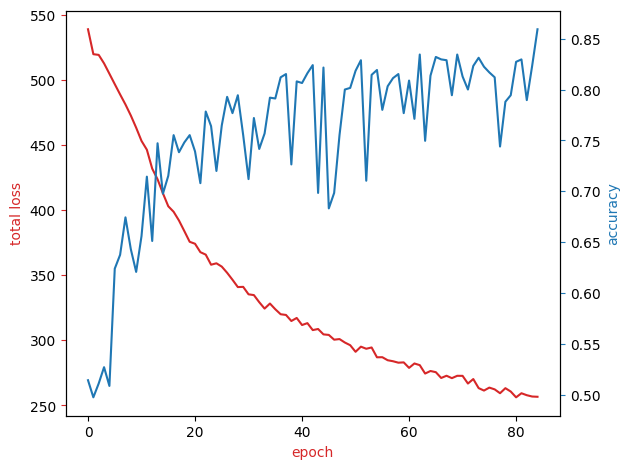

In [ ]:
file_path_acc = '/content/drive/MyDrive/model_imdb_small-acc'
file_path_loss = '/content/drive/MyDrive/model_imdb_small-loss'

# Load from Google Drive
with open(file_path_acc.pkl, 'rb') as f:
    acc_epoch = pickle.load(f)

with open(file_path_loss.pkl, 'rb') as f:
    cum_loss_list = pickle.load(f)
plot(cum_loss_list,acc_epoch)

In [ ]:
import io
model_ = Net(vocab_size=vocab_size, num_class=2).to(device)
model_.load_state_dict(torch.load('/content/model_imdb_small.pth', map_location=device))
evaluate(test_dataloader, model_)
# 83% accuracy

100%|██████████| 782/782 [04:19<00:00,  3.02it/s]


0.83112

In [ ]:
!pip install 'portalocker>=2.0.0'

#### Training on full AG dataset (Data preprocessing and training)

In [ ]:
train_iter_ag_news = AG_NEWS(split="train")

num_class_ag_news = len(set([label for (label, text) in train_iter_ag_news ]))
num_class_ag_news

# Splitting the dataset into training and testing iterators.
train_iter_ag_news, test_iter_ag_news = AG_NEWS()

# Converting the training and testing iterators to map-style datasets.
train_dataset_ag_news = to_map_style_dataset(train_iter_ag_news)
test_dataset_ag_news = to_map_style_dataset(test_iter_ag_news)

# Determining the number of samples to be used for training and validation (5% for validation).
# Training on the full dataset
num_train_ag_news = int(len(train_dataset_ag_news) * 0.95)

# Randomly spliting the training dataset into training and validation datasets using `random_split`.
# The training dataset will contain 95% of the samples, and the validation dataset will contain the remaining 5%.
split_train_ag_news_, split_valid_ag_news_ = random_split(train_dataset_ag_news, [num_train_ag_news, len(train_dataset_ag_news) - num_train_ag_news])

# Making the training set smaller to allow it to run fast as an example.
# IF WANT TO TRAIN ON THE AG_NEWS DATASET, then one should COMMENT OUT THE 2 LINEs BELOW.
# HOWEVER, TRAINING WILL TAKE A LONG TIME
# Training on a limited dataset
num_train_ag_news = int(len(train_dataset_ag_news) * 0.05)
split_train_ag_news_, _ = random_split(split_train_ag_news_, [num_train_ag_news, len(split_train_ag_news_) - num_train_ag_news])


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

def label_pipeline(x):
   return int(x) - 1

from torch.nn.utils.rnn import pad_sequence

def collate_batch_ag_news(batch):
    label_list, text_list = [], []
    for _label, _text in batch:
        label_list.append(label_pipeline(_label))
        text_list.append(torch.tensor(text_pipeline(_text), dtype=torch.int64))


    label_list = torch.tensor(label_list, dtype=torch.int64)
    text_list = pad_sequence(text_list, batch_first=True)


    return label_list.to(device), text_list.to(device)

BATCH_SIZE = 32

train_dataloader_ag_news = DataLoader(
    split_train_ag_news_, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_batch_ag_news
)
valid_dataloader_ag_news = DataLoader(
    split_valid_ag_news_, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_batch_ag_news
)
test_dataloader_ag_news = DataLoader(
    test_dataset_ag_news, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_batch_ag_news
)


model_ag_news = Net(num_class=4,vocab_size=vocab_size).to(device)
model_ag_news.to(device)



LR=1
criterion = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model_ag_news.parameters(), lr=LR)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, 1.0, gamma=0.1)
save_dir = ""
file_name = "model_AG News small1.pth"
train_model(model=model_ag_news, optimizer=optimizer, criterion=criterion, train_dataloader=train_dataloader_ag_news, valid_dataloader=valid_dataloader_ag_news,  epochs=2, save_dir=save_dir, file_name=file_name)


  0%|          | 0/2 [00:00<?, ?it/s]

Epoch 1/2 - Loss: 267.7394815683365


 50%|█████     | 1/2 [00:25<00:25, 25.97s/it]

0.2535
Epoch 2/2 - Loss: 261.4039137363434


100%|██████████| 2/2 [00:55<00:00, 27.53s/it]

Training time: 55.06064701080322


#### The model shown above was trained for only 2 epochs as a quick demonstration. For comprehensive evaluation, I conducted a separate training run for up to 100 epochs. Below, I load those model parameters to evaluate the final accuracy, along with the loss and accuracy curves from that extended training session.

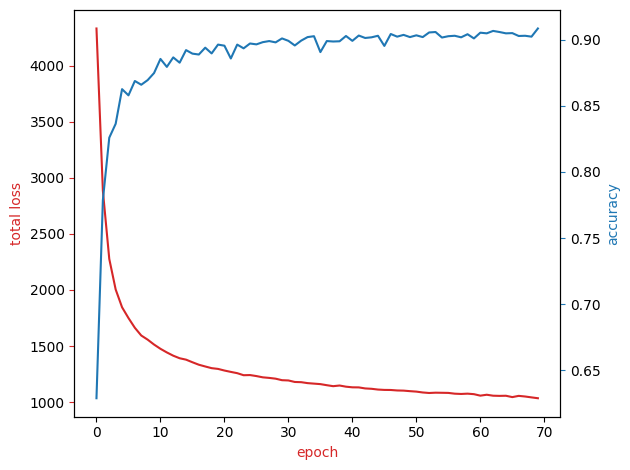

In [ ]:
#Pretrained on the full dataset

file_path_acc = '/content/drive/MyDrive/model_AGNews_small1-acc'
file_path_loss = '/content/drive/MyDrive/model_AGNews_small1-loss'

# Load from Google Drive
with open(file_path_acc.pkl, 'rb') as f:
    acc_epoch = pickle.load(f)

with open(file_path_loss.pkl, 'rb') as f:
    cum_loss_list = pickle.load(f)
plot(cum_loss_list,acc_epoch)

In [ ]:
#Evaluate the accuracy of the fully trained model on AG News

In [ ]:

model_ag_news_ = Net(vocab_size=vocab_size, num_class=4).to(device)
model_ag_news_.load_state_dict(torch.load('/content/model_AGNews_small1.pth', map_location=device))
evaluate(test_dataloader_ag_news, model_ag_news_)

100%|██████████| 238/238 [00:07<00:00, 30.74it/s]


0.9048684210526315

#### Fine-tuning this model which was trained on a full AG news dataset, over the IMDB dataset

In [ ]:
model_fine1 = Net(vocab_size=vocab_size, num_class=4).to(device)
model_fine1.load_state_dict(torch.load('/content/model_AGNews_small1.pth', map_location=device))


<All keys matched successfully>

In [ ]:

in_features = model_fine1.classifier.in_features
print("Original final layer:", model_fine1.classifier)
print("Input dimention  final layer:", in_features)

Original final layer: Linear(in_features=100, out_features=4, bias=True)
Input dimention  final layer: 100


In [ ]:
model_fine1.classifier = nn.Linear(in_features, 2)
model_fine1.to(device)

Net(
  (emb): Embedding(400000, 100)
  (pos_encoder): PositionalEncoding(
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (transformer_encoder): TransformerEncoder(
    (layers): ModuleList(
      (0-1): 2 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=100, out_features=100, bias=True)
        )
        (linear1): Linear(in_features=100, out_features=128, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
        (linear2): Linear(in_features=128, out_features=100, bias=True)
        (norm1): LayerNorm((100,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((100,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.1, inplace=False)
        (dropout2): Dropout(p=0.1, inplace=False)
      )
    )
  )
  (classifier): Linear(in_features=100, out_features=2, bias=True)
)

In [ ]:
for name, param in model_fine1.named_parameters():
    print(f"{name} requires_grad: {param.requires_grad}")

emb.weight requires_grad: False
transformer_encoder.layers.0.self_attn.in_proj_weight requires_grad: True
transformer_encoder.layers.0.self_attn.in_proj_bias requires_grad: True
transformer_encoder.layers.0.self_attn.out_proj.weight requires_grad: True
transformer_encoder.layers.0.self_attn.out_proj.bias requires_grad: True
transformer_encoder.layers.0.linear1.weight requires_grad: True
transformer_encoder.layers.0.linear1.bias requires_grad: True
transformer_encoder.layers.0.linear2.weight requires_grad: True
transformer_encoder.layers.0.linear2.bias requires_grad: True
transformer_encoder.layers.0.norm1.weight requires_grad: True
transformer_encoder.layers.0.norm1.bias requires_grad: True
transformer_encoder.layers.0.norm2.weight requires_grad: True
transformer_encoder.layers.0.norm2.bias requires_grad: True
transformer_encoder.layers.1.self_attn.in_proj_weight requires_grad: True
transformer_encoder.layers.1.self_attn.in_proj_bias requires_grad: True
transformer_encoder.layers.1.sel

In [ ]:

LR=1
criterion = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model_fine1.parameters(), lr=LR)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, 1.0, gamma=0.1)
save_dir = ""
file_name = "model_fine1.pth"
train_model(model=model_fine1, optimizer=optimizer, criterion=criterion, train_dataloader=train_dataloader, valid_dataloader=valid_dataloader,  epochs=2,  save_dir=save_dir ,file_name=file_name )


  0%|          | 0/2 [00:00<?, ?it/s]

Epoch 1/2 - Loss: 28.001281261444092


 50%|█████     | 1/2 [01:09<01:09, 69.73s/it]

0.4904
Epoch 2/2 - Loss: 27.85107070207596


100%|██████████| 2/2 [02:19<00:00, 69.79s/it]

0.5128
Training time: 139.5833775997162


#### The model shown above was trained for only 2 epochs as a quick demonstration. For comprehensive evaluation, I conducted a separate training run for up to 100 epochs. Below, I load those model parameters to evaluate the final accuracy, along with the loss and accuracy curves from that extended training session.

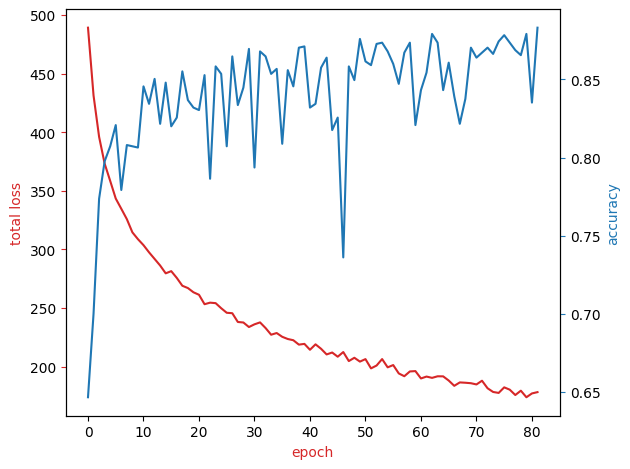

In [ ]:
file_path_acc = '/content/model-fine1-acc'
file_path_loss = '/content/model-fine1-loss'

# Load from Google Drive
with open(file_path_acc.pkl, 'rb') as f:
    acc_epoch = pickle.load(f)

with open(file_path_loss.pkl, 'rb') as f:
    cum_loss_list = pickle.load(f)

plot(cum_loss_list,acc_epoch)

In [ ]:
urlopened = urlopen('https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/e0WOHKh5dnrbC2lGhpsMMw/model-fine1.pth')
model_fine1_ = Net(vocab_size=vocab_size, num_class=2).to(device)
model_fine1_.load_state_dict(torch.load('/content/model_fine1.pth', map_location=device))
evaluate(test_dataloader, model_fine1_)
#Accuracy of the model fine tuned on on the full IMDB dataset with all the layers unfrozen of the model pretrained on AG news dataset
#Accuracy = 86%

100%|██████████| 782/782 [04:21<00:00,  2.99it/s]


0.86128

#### Next only the final layer of the model trained on AG news dataset is unfrozen for fine-tuning on the full IMDB dataset

In [ ]:
model_fine2 = Net(vocab_size=vocab_size, num_class=4).to(device)
model_fine2.load_state_dict(torch.load('/content/model_AGNews_small1.pth', map_location=device))

<All keys matched successfully>

In [ ]:
# Freeze all layers in the model
for param in model_fine2.parameters():
    param.requires_grad = False

In [ ]:
dim=model_fine2.classifier.in_features

In [ ]:
model_fine2.classifier = nn.Linear(dim, 2)

In [ ]:
model_fine2.to(device)


Net(
  (emb): Embedding(400000, 100)
  (pos_encoder): PositionalEncoding(
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (transformer_encoder): TransformerEncoder(
    (layers): ModuleList(
      (0-1): 2 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=100, out_features=100, bias=True)
        )
        (linear1): Linear(in_features=100, out_features=128, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
        (linear2): Linear(in_features=128, out_features=100, bias=True)
        (norm1): LayerNorm((100,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((100,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.1, inplace=False)
        (dropout2): Dropout(p=0.1, inplace=False)
      )
    )
  )
  (classifier): Linear(in_features=100, out_features=2, bias=True)
)

In [ ]:

LR=1
criterion = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model_fine2.parameters(), lr=LR)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, 1.0, gamma=0.1)
save_dir = ""
file_name = "model_fine2.pth"
train_model(model=model_fine2, optimizer=optimizer, criterion=criterion, train_dataloader=train_dataloader, valid_dataloader=valid_dataloader,  epochs=2,  save_dir=save_dir ,file_name=file_name )


  0%|          | 0/2 [00:00<?, ?it/s]

Epoch 1/2 - Loss: 27.847393572330475


 50%|█████     | 1/2 [00:31<00:31, 31.86s/it]

0.5576
Epoch 2/2 - Loss: 27.628926813602448


100%|██████████| 2/2 [01:04<00:00, 32.00s/it]

Training time: 64.0102367401123


#### The model shown above was trained for only 2 epochs as a quick demonstration. For comprehensive evaluation, I conducted a separate training run for up to 100 epochs. Below, I load those model parameters to evaluate the final accuracy, along with the loss and accuracy curves from that extended training session.

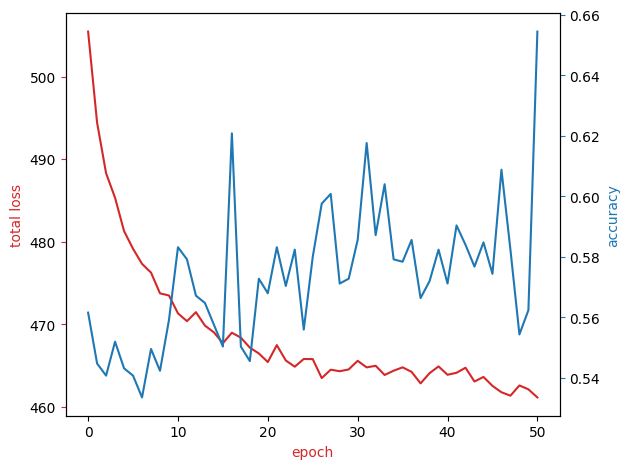

In [ ]:
file_path_acc = '/content/model-fine2-acc'
file_path_loss = '/content/model-fine2-loss'

# Load from Google Drive
with open(file_path_acc.pkl, 'rb') as f:
    acc_epoch = pickle.load(f)

with open(file_path_loss.pkl, 'rb') as f:
    cum_loss_list = pickle.load(f)
plot(cum_loss_list,acc_epoch)

In [ ]:
model_fine2_ = Net(vocab_size=vocab_size, num_class=2).to(device)
model_fine2_.load_state_dict(torch.load('/content/model_fine2.pth', map_location=device))
evaluate(test_dataloader, model_fine2_)
#the accuracy of the pretrained model (pretrained on AG news dataset) fine-tuned on full IMDB dataset with only last layers unfrozen.
#accuracy=64%

100%|██████████| 782/782 [04:20<00:00,  3.00it/s]


0.63848

#### Parameter Efficient fine-tuning using Adapters method

In [ ]:
class FeatureAdapter(nn.Module):
    """
    Attributes:
        size (int): The bottleneck dimension to which the embeddings are temporarily reduced.
        model_dim (int): The original dimension of the embeddings or features in the transformer model.
    """
    def __init__(self, bottleneck_size=50, model_dim=100):
        super().__init__()
        self.bottleneck_transform = nn.Sequential(
            nn.Linear(model_dim, bottleneck_size),  # Down-projecting to a smaller dimension
            nn.ReLU(),                             # Applying non-linearity
            nn.Linear(bottleneck_size, model_dim)  # Up-projecting back to the original dimension
        )

    def forward(self, x):
        """
        Forward pass of the FeatureAdapter. Applies the bottleneck transformation to the input
        tensor and adds a skip connection.

        Args:
            x (Tensor): Input tensor with shape (batch_size, seq_length, model_dim).

        Returns:
            Tensor: Output tensor after applying the adapter transformation and skip connection,
                    maintaining the original input shape.
        """
        transformed_features = self.bottleneck_transform(x)  # Transforming features through the bottleneck
        output_with_residual = transformed_features + x      # Adding the residual connection
        return output_with_residual

In [ ]:
class Adapted(nn.Module):
    def __init__(self, linear,bottleneck_size=None):
        super(Adapted, self).__init__()
        self.linear = linear
        model_dim = linear.out_features
        if bottleneck_size is None:
          bottleneck_size = model_dim//2   # Defining default bottleneck size as half the model_dim

        # Initializing FeatureAdapter with calculated bottleneck_size and model_dim
        self.adaptor = FeatureAdapter(bottleneck_size=bottleneck_size, model_dim=model_dim)

    def forward(self, x):
        # First, the input x is passed through the linear layer
        x=self.linear(x)
        # Then it's adapted using FeatureAdapter
        x= self.adaptor(x)
        return x

In [ ]:
model_adapters = Net(vocab_size=vocab_size, num_class=4).to(device)
model_adapters.load_state_dict(torch.load('/content/model_AGNews_small1.pth', map_location=device))

<All keys matched successfully>

In [ ]:
for param in model_adapters.parameters():
    param.requires_grad = False

dim= model_adapters.classifier.in_features
model_adapters.classifier = nn.Linear(dim, 2)

In [ ]:
my_example_layer=model_adapters.transformer_encoder.layers[0].linear1
print(my_example_layer)

Linear(in_features=100, out_features=128, bias=True)


In [ ]:
my_adapeted_layer=Adapted(my_example_layer)
print(my_adapeted_layer)

Adapted(
  (linear): Linear(in_features=100, out_features=128, bias=True)
  (adaptor): FeatureAdapter(
    (bottleneck_transform): Sequential(
      (0): Linear(in_features=128, out_features=64, bias=True)
      (1): ReLU()
      (2): Linear(in_features=64, out_features=128, bias=True)
    )
  )
)


In [ ]:
for parm in my_adapeted_layer.parameters():
    print(parm.requires_grad)

False
False
True
True
True
True


In [ ]:
# Adapting a specific layer
#model_adapters.transformer_encoder.layers[0].linear1=Adapted(my_example_layer)

In [ ]:
# Finding number of layers
N_layers=len(model_adapters.transformer_encoder.layers)

In [ ]:
# Traverse model and adapt
for n in range(N_layers):
  encoder=model_adapters.transformer_encoder.layers[n]
  if encoder.linear1:
    print(" before linear1")
    print(encoder.linear1)
    model_adapters.transformer_encoder.layers[n].linear1=Adapted(encoder.linear1, bottleneck_size=24)
    print(" after  linear1")
    print(model_adapters.transformer_encoder.layers[n].linear1)

  if encoder.linear2:
    print(" before linear2")
    print(model_adapters.transformer_encoder.layers[n].linear2)
    model_adapters.transformer_encoder.layers[n].linear2=Adapted(encoder.linear2, bottleneck_size=24)
    print(" after linear2")
    print(model_adapters.transformer_encoder.layers[n].linear2)

 before linear1
Linear(in_features=100, out_features=128, bias=True)
 after  linear1
Adapted(
  (linear): Linear(in_features=100, out_features=128, bias=True)
  (adaptor): FeatureAdapter(
    (bottleneck_transform): Sequential(
      (0): Linear(in_features=128, out_features=24, bias=True)
      (1): ReLU()
      (2): Linear(in_features=24, out_features=128, bias=True)
    )
  )
)
 before linear2
Linear(in_features=128, out_features=100, bias=True)
 after linear2
Adapted(
  (linear): Linear(in_features=128, out_features=100, bias=True)
  (adaptor): FeatureAdapter(
    (bottleneck_transform): Sequential(
      (0): Linear(in_features=100, out_features=24, bias=True)
      (1): ReLU()
      (2): Linear(in_features=24, out_features=100, bias=True)
    )
  )
)
 before linear1
Linear(in_features=100, out_features=128, bias=True)
 after  linear1
Adapted(
  (linear): Linear(in_features=100, out_features=128, bias=True)
  (adaptor): FeatureAdapter(
    (bottleneck_transform): Sequential(
     

In [ ]:
# Send model to device
model_adapters.to(device)

Net(
  (emb): Embedding(400000, 100)
  (pos_encoder): PositionalEncoding(
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (transformer_encoder): TransformerEncoder(
    (layers): ModuleList(
      (0-1): 2 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=100, out_features=100, bias=True)
        )
        (linear1): Adapted(
          (linear): Linear(in_features=100, out_features=128, bias=True)
          (adaptor): FeatureAdapter(
            (bottleneck_transform): Sequential(
              (0): Linear(in_features=128, out_features=24, bias=True)
              (1): ReLU()
              (2): Linear(in_features=24, out_features=128, bias=True)
            )
          )
        )
        (dropout): Dropout(p=0.1, inplace=False)
        (linear2): Adapted(
          (linear): Linear(in_features=128, out_features=100, bias=True)
          (adaptor): FeatureAdapter(
            (bottleneck_transform): 

In [ ]:
LR=1
criterion = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model_adapters.parameters(), lr=LR)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, 1.0, gamma=0.1)
save_dir = ""
file_name = "model_adapters.pth"
train_model(model=model_adapters, optimizer=optimizer, criterion=criterion, train_dataloader=train_dataloader, valid_dataloader=valid_dataloader,  epochs=2,  save_dir=save_dir ,file_name=file_name )

  0%|          | 0/2 [00:00<?, ?it/s]

Epoch 1/2 - Loss: 28.114633679389954


 50%|█████     | 1/2 [00:52<00:52, 52.83s/it]

0.4864
Epoch 2/2 - Loss: 27.60458406805992


100%|██████████| 2/2 [01:44<00:00, 52.12s/it]

Training time: 104.24313163757324


#### The model shown above was trained for only 2 epochs as a quick demonstration. For comprehensive evaluation, I conducted a separate training run for up to 100 epochs. Below, I load those model parameters to evaluate the final accuracy, along with the loss and accuracy curves from that extended training session.

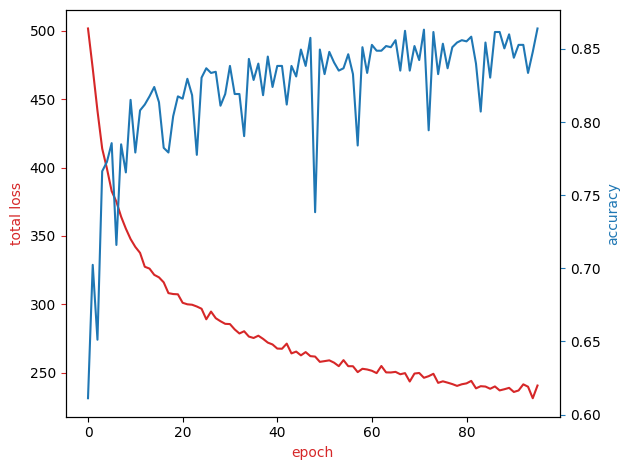

In [ ]:
file_path_acc = '/content/model-adapters-acc'
file_path_loss = '/content/model-adapters-loss'

# Load from Google Drive
with open(file_path_acc.pkl, 'rb') as f:
    acc_epoch = pickle.load(f)

with open(file_path_loss.pkl, 'rb') as f:
    cum_loss_list = pickle.load(f)
plot(cum_loss_list,acc_epoch)

In [ ]:
model_adapters_ = Net(vocab_size=vocab_size, num_class=2).to(device)
for n in range(N_layers):
  encoder=model_adapters_.transformer_encoder.layers[n]
  if encoder.linear1:
    print(" before linear1")
    print(encoder.linear1)
    model_adapters_.transformer_encoder.layers[n].linear1=Adapted(encoder.linear1, bottleneck_size=24)
    print(" after  linear1")
    print(model_adapters_.transformer_encoder.layers[n].linear1)

  if encoder.linear2:
    print(" before linear2")
    print(model_adapters_.transformer_encoder.layers[n].linear2)
    model_adapters_.transformer_encoder.layers[n].linear2=Adapted(encoder.linear2, bottleneck_size=24)
    print(" after linear2")
    print(model_adapters_.transformer_encoder.layers[n].linear2)

model_adapters_.to(device)
for param in model_adapters_.parameters():
    param.requires_grad = False


model_adapters_.load_state_dict(torch.load('/content/model-adapters.pth', map_location=device))
evaluate(test_dataloader, model_adapters_)
#accuracy of the adapted model=86percent which is as good as the fully funetuned model

 before linear1
Linear(in_features=100, out_features=128, bias=True)
 after  linear1
Adapted(
  (linear): Linear(in_features=100, out_features=128, bias=True)
  (adaptor): FeatureAdapter(
    (bottleneck_transform): Sequential(
      (0): Linear(in_features=128, out_features=24, bias=True)
      (1): ReLU()
      (2): Linear(in_features=24, out_features=128, bias=True)
    )
  )
)
 before linear2
Linear(in_features=128, out_features=100, bias=True)
 after linear2
Adapted(
  (linear): Linear(in_features=128, out_features=100, bias=True)
  (adaptor): FeatureAdapter(
    (bottleneck_transform): Sequential(
      (0): Linear(in_features=100, out_features=24, bias=True)
      (1): ReLU()
      (2): Linear(in_features=24, out_features=100, bias=True)
    )
  )
)
 before linear1
Linear(in_features=100, out_features=128, bias=True)
 after  linear1
Adapted(
  (linear): Linear(in_features=100, out_features=128, bias=True)
  (adaptor): FeatureAdapter(
    (bottleneck_transform): Sequential(
     

100%|██████████| 782/782 [05:08<00:00,  2.54it/s]


0.85652

#### Implementing LORA

In [ ]:
from urllib.request import urlopen
import io

urlopened = urlopen('https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/9c3Dh2O_jsYBShBuchUNlg/model-AG%20News%20small1.pth')
model_lora = Net(vocab_size=vocab_size, num_class=4).to(device)
model_lora.load_state_dict(torch.load('/content/model_AGNews_small1.pth', map_location=device))

# Here, you freeze all layers:
for parm in model_lora.parameters():
    parm.requires_grad=False
model_lora

Net(
  (emb): Embedding(400000, 100)
  (pos_encoder): PositionalEncoding(
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (transformer_encoder): TransformerEncoder(
    (layers): ModuleList(
      (0-1): 2 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=100, out_features=100, bias=True)
        )
        (linear1): Linear(in_features=100, out_features=128, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
        (linear2): Linear(in_features=128, out_features=100, bias=True)
        (norm1): LayerNorm((100,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((100,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.1, inplace=False)
        (dropout2): Dropout(p=0.1, inplace=False)
      )
    )
  )
  (classifier): Linear(in_features=100, out_features=4, bias=True)
)

In [ ]:
dim= model_lora.classifier.in_features
model_lora.classifier = nn.Linear(dim, 2)

In [ ]:
class LoRALayer(torch.nn.Module):
    def __init__(self, in_dim, out_dim, rank, alpha):
        super().__init__()
        std_dev = 1 / torch.sqrt(torch.tensor(rank).float())
        self.A = torch.nn.Parameter(torch.randn(in_dim, rank) * std_dev)

        self.B = torch.nn.Parameter(torch.zeros(rank, out_dim))
        self.alpha = alpha

    def forward(self, x):
        x = self.alpha * (x @ self.A @ self.B)
        return x

class LinearWithLoRA(torch.nn.Module):
    def __init__(self, linear, rank, alpha):
        super().__init__()
        self.linear = linear.to(device)
        self.lora = LoRALayer(
            linear.in_features, linear.out_features, rank, alpha
        ).to(device)

    def forward(self, x):

        return self.linear(x) + self.lora(x)

In [ ]:
model_lora.classifier = LinearWithLoRA(model_lora.classifier, rank=2, alpha=0.1).to(device)

In [ ]:


LR=1
criterion = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model_adapters.parameters(), lr=LR)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, 1.0, gamma=0.1)
save_dir = ""
file_name = "model_lora.pth"
train_model(model=model_lora, optimizer=optimizer, criterion=criterion, train_dataloader=train_dataloader, valid_dataloader=valid_dataloader,  epochs=2,  save_dir=save_dir ,file_name=file_name )


  0%|          | 0/2 [00:00<?, ?it/s]

Epoch 1/2 - Loss: 27.795613408088684


 50%|█████     | 1/2 [00:31<00:31, 31.98s/it]

0.5352
Epoch 2/2 - Loss: 27.65350890159607


100%|██████████| 2/2 [01:03<00:00, 31.91s/it]

Training time: 63.83133363723755


#### The model shown above was trained for only 2 epochs as a quick demonstration. For comprehensive evaluation, I conducted a separate training run for up to 100 epochs. Below, I load those model parameters to evaluate the final accuracy, along with the loss and accuracy curves from that extended training session.

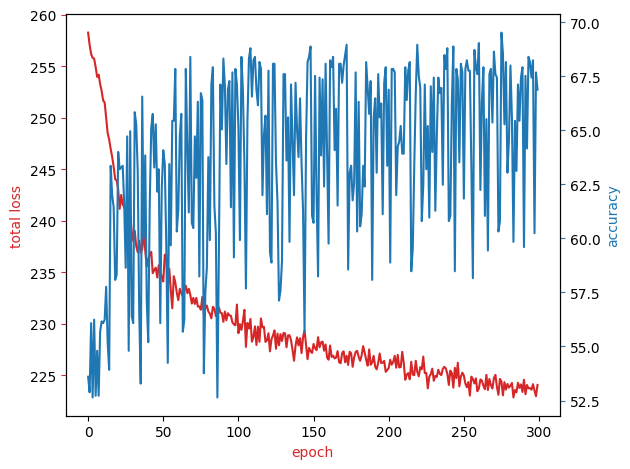

In [1]:
file_path_acc = '/content/model-lora-final2-acc.pkl'
file_path_loss = '/content/model-lora-final2-loss.pkl'

# Load from Google Drive
with open(file_path_acc.pkl, 'rb') as f:
    acc_epoch = pickle.load(f)

with open(file_path_loss.pkl, 'rb') as f:
    cum_loss_list = pickle.load(f)

plot(cum_loss_list,acc_epoch)

In [ ]:
from urllib.request import urlopen
import io


model_lora = Net(vocab_size=vocab_size, num_class=4).to(device)
model_lora.load_state_dict(torch.load('/content/model_AGNews_small1.pth', map_location=device))

# Here, I freeze all layers:
for parm in model_lora.parameters():
    parm.requires_grad=False

model_lora.classifier = LinearWithLoRA(model_lora.classifier, rank=2, alpha=0.1).to(device)


model_adapters_.load_state_dict(torch.load('/content/model_lora.pth', map_location=device))
evaluate(test_dataloader, model_adapters_)

69.064

#### Implementing QLORA

In [ ]:
!pip install --user datasets

In [ ]:
!pip install torch==2.2.2
!pip install torchtext==0.17.2
!pip install portalocker==2.8.2
!pip install torchdata==0.7.1
!pip install pandas
!pip install matplotlib==3.9.0 scikit-learn==1.5.0
!pip install numpy==1.26.0
!pip install huggingface_hub
!pip install --user datasets
!pip install transformers
!pip install trl==0.11 peft==0.11.1 bitsandbytes==0.43.1

  Using cached torch-2.2.2-cp312-cp312-manylinux1_x86_64.whl.metadata (25 kB)
Using cached torch-2.2.2-cp312-cp312-manylinux1_x86_64.whl (755.5 MB)
  Attempting uninstall: torch
    Found existing installation: torch 2.11.0
    Uninstalling torch-2.11.0:
      Successfully uninstalled torch-2.11.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
bitsandbytes 0.49.2 requires torch<3,>=2.3, but you have torch 2.2.2 which is incompatible.
torchaudio 2.10.0+cu128 requires torch==2.10.0, but you have torch 2.2.2 which is incompatible.
torchtune 0.6.1 requires torchdata==0.11.0, but you have torchdata 0.7.1 which is incompatible.
torchvision 0.25.0+cu128 requires torch==2.10.0, but you have torch 2.2.2 which is incompatible.


  Using cached bitsandbytes-0.43.1-py3-none-manylinux_2_24_x86_64.whl.metadata (2.2 kB)
Using cached bitsandbytes-0.43.1-py3-none-manylinux_2_24_x86_64.whl (119.8 MB)
  Attempting uninstall: bitsandbytes
    Found existing installation: bitsandbytes 0.49.2
    Uninstalling bitsandbytes-0.49.2:
      Successfully uninstalled bitsandbytes-0.49.2


In [ ]:
!pip install -U bitsandbytes --no-deps
!pip install --upgrade torch

  Using cached bitsandbytes-0.49.2-py3-none-manylinux_2_24_x86_64.whl.metadata (10 kB)
Using cached bitsandbytes-0.49.2-py3-none-manylinux_2_24_x86_64.whl (60.7 MB)
  Attempting uninstall: bitsandbytes
    Found existing installation: bitsandbytes 0.43.1
    Uninstalling bitsandbytes-0.43.1:
      Successfully uninstalled bitsandbytes-0.43.1
  Using cached torch-2.11.0-cp312-cp312-manylinux_2_28_x86_64.whl.metadata (29 kB)
Using cached torch-2.11.0-cp312-cp312-manylinux_2_28_x86_64.whl (530.7 MB)
  Attempting uninstall: torch
    Found existing installation: torch 2.2.2
    Uninstalling torch-2.2.2:
      Successfully uninstalled torch-2.2.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
torchtext 0.17.2 requires torch==2.2.2, but you have torch 2.11.0 which is incompatible.
torchaudio 2.10.0+cu128 requires torch==2.10.0, but you have torch 2.11.0 which is inc

In [ ]:
!pip install "accelerate>=1.1.0" bitsandbytes peft transformers

In [ ]:
# First, uninstall current versions
!pip uninstall torch torchvision torchaudio -y

# Reinstall with matching versions (CUDA 12.1 is stable and widely supported)
!pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu121

# Restart the runtime after installation
import os
os.kill(os.getpid(), 9)

Found existing installation: torch 2.11.0
Uninstalling torch-2.11.0:
  Successfully uninstalled torch-2.11.0
Found existing installation: torchvision 0.25.0+cu128
Uninstalling torchvision-0.25.0+cu128:
  Successfully uninstalled torchvision-0.25.0+cu128
Found existing installation: torchaudio 2.10.0+cu128
Uninstalling torchaudio-2.10.0+cu128:
  Successfully uninstalled torchaudio-2.10.0+cu128
Looking in indexes: https://download.pytorch.org/whl/cu121
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 780.4/780.4 MB ? eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.3/7.3 MB 27.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 119.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 3.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 188.7/188.7 MB 571.9 kB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 209.6/209.6 MB ? eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.2/6.2 MB 53.9 MB/s eta 0:00:

In [ ]:
import torch
import matplotlib.pyplot as plt
# to suppress warnings generated by the code:
def warn(*args, **kwargs):
    pass
import warnings
warnings.warn = warn
warnings.filterwarnings('ignore')

import json

import numpy as np

from datasets import load_dataset

from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments, BitsAndBytesConfig

from peft import LoraConfig, get_peft_model, TaskType, replace_lora_weights_loftq, prepare_model_for_kbit_training

In [ ]:
from datasets import load_dataset
imdb = load_dataset("imdb")

In [ ]:
!pip install evaluate

In [ ]:
small_train_dataset = imdb["train"].shuffle(seed=42).select([i for i in list(range(50))])
small_test_dataset = imdb["test"].shuffle(seed=42).select([i for i in list(range(50))])
medium_train_dataset = imdb["train"].shuffle(seed=42).select([i for i in list(range(3000))])
medium_test_dataset = imdb["test"].shuffle(seed=42).select([i for i in list(range(300))])

tokenizer = AutoTokenizer.from_pretrained("distilbert-base-uncased")

my_tokens=tokenizer(imdb['train'][0]['text'])

# Print the tokenized input IDs
print("Input IDs:", my_tokens['input_ids'])

# Print the attention mask
print("Attention Mask:", my_tokens['attention_mask'])

# If token_type_ids is present, print it
if 'token_type_ids' in my_tokens:
    print("Token Type IDs:", my_tokens['token_type_ids'])

def preprocess_function(examples):
    return tokenizer(examples["text"], padding=True, truncation=True, max_length=512)

small_tokenized_train = small_train_dataset.map(preprocess_function, batched=True)
small_tokenized_test = small_test_dataset.map(preprocess_function, batched=True)
medium_tokenized_train = medium_train_dataset.map(preprocess_function, batched=True)
medium_tokenized_test = medium_test_dataset.map(preprocess_function, batched=True)

Input IDs: [101, 1045, 12524, 1045, 2572, 8025, 1011, 3756, 2013, 2026, 2678, 3573, 2138, 1997, 2035, 1996, 6704, 2008, 5129, 2009, 2043, 2009, 2001, 2034, 2207, 1999, 3476, 1012, 1045, 2036, 2657, 2008, 2012, 2034, 2009, 2001, 8243, 2011, 1057, 1012, 1055, 1012, 8205, 2065, 2009, 2412, 2699, 2000, 4607, 2023, 2406, 1010, 3568, 2108, 1037, 5470, 1997, 3152, 2641, 1000, 6801, 1000, 1045, 2428, 2018, 2000, 2156, 2023, 2005, 2870, 1012, 1026, 7987, 1013, 1028, 1026, 7987, 1013, 1028, 1996, 5436, 2003, 8857, 2105, 1037, 2402, 4467, 3689, 3076, 2315, 14229, 2040, 4122, 2000, 4553, 2673, 2016, 2064, 2055, 2166, 1012, 1999, 3327, 2016, 4122, 2000, 3579, 2014, 3086, 2015, 2000, 2437, 2070, 4066, 1997, 4516, 2006, 2054, 1996, 2779, 25430, 14728, 2245, 2055, 3056, 2576, 3314, 2107, 2004, 1996, 5148, 2162, 1998, 2679, 3314, 1999, 1996, 2142, 2163, 1012, 1999, 2090, 4851, 8801, 1998, 6623, 7939, 4697, 3619, 1997, 8947, 2055, 2037, 10740, 2006, 4331, 1010, 2016, 2038, 3348, 2007, 2014, 3689, 3836, 

Map:   0%|          | 0/50 [00:00<?, ? examples/s]

In [ ]:


import evaluate
def compute_metrics(eval_pred):
   load_accuracy = evaluate.load("accuracy")


   logits, labels = eval_pred
   predictions = np.argmax(logits, axis=-1)
   accuracy = load_accuracy.compute(predictions=predictions, references=labels)["accuracy"]

   return {"accuracy": accuracy}


config_bnb = BitsAndBytesConfig(
    load_in_4bit=True, # quantizing the model to 4-bits when loading
    bnb_4bit_quant_type="nf4", # using a special 4-bit data type for weights initialized from a normal distribution
    bnb_4bit_use_double_quant=True, # nested quantization scheme to quantize the already quantized weights
    bnb_4bit_compute_dtype=torch.bfloat16, # using bfloat16 for faster computation
    llm_int8_skip_modules=["classifier", "pre_classifier"] #  Should not convert the "classifier" and "pre_classifier" layers to 8-bit
)

In [ ]:
id2label = {0: "NEGATIVE", 1: "POSITIVE"}
label2id = dict((v,k) for k,v in id2label.items())
model_qlora = AutoModelForSequenceClassification.from_pretrained("distilbert-base-uncased",
                                                                 id2label=id2label,
                                                                 label2id=label2id,
                                                                 num_labels=2,
                                                                 quantization_config=config_bnb
                                                                )



model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [ ]:
lora_config = LoraConfig(
    task_type=TaskType.SEQ_CLS,  # Specifing the task type as sequence classification
    r=8,  # Ranking of the low-rank matrices
    lora_alpha=16,  # Scaling factor
    lora_dropout=0.1,  # Dropout rate
    target_modules=['q_lin','k_lin','v_lin'] # which modules
)

peft_model_qlora = get_peft_model(model_qlora, lora_config)

In [ ]:
replace_lora_weights_loftq(peft_model_qlora)
print(peft_model_qlora)

peft_model_qlora.print_trainable_parameters()

PeftModelForSequenceClassification(
  (base_model): LoraModel(
    (model): DistilBertForSequenceClassification(
      (distilbert): DistilBertModel(
        (embeddings): Embeddings(
          (word_embeddings): Embedding(30522, 768, padding_idx=0)
          (position_embeddings): Embedding(512, 768)
          (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
          (dropout): Dropout(p=0.1, inplace=False)
        )
        (transformer): Transformer(
          (layer): ModuleList(
            (0-5): 6 x TransformerBlock(
              (attention): DistilBertSelfAttention(
                (q_lin): lora.Linear4bit(
                  (base_layer): Linear4bit(in_features=768, out_features=768, bias=True)
                  (lora_dropout): ModuleDict(
                    (default): Dropout(p=0.1, inplace=False)
                  )
                  (lora_A): ModuleDict(
                    (default): Linear(in_features=768, out_features=8, bias=False)
                  

In [ ]:
training_args = TrainingArguments(
    output_dir="./results_qlora",
    num_train_epochs=10,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=64,
    learning_rate=2e-5,
    eval_strategy="epoch",
    weight_decay=0.01
)

In [ ]:
trainer_qlora = Trainer(
    model=peft_model_qlora,
    args=training_args,
    train_dataset=medium_tokenized_train,
    eval_dataset=medium_tokenized_test,
    processing_class=tokenizer,
    compute_metrics=compute_metrics)


trainer_qlora.train()

Epoch,Training Loss,Validation Loss,Accuracy
1,No log,0.631811,0.800000
2,No log,0.387283,0.820000
3,0.524787,0.371161,0.830000
4,0.524787,0.362874,0.826667
5,0.524787,0.358883,0.823333
6,0.310401,0.357699,0.836667
7,0.310401,0.354880,0.826667
8,0.284938,0.355036,0.830000
9,0.284938,0.355154,0.836667
10,0.284938,0.357331,0.840000


TrainOutput(global_step=1880, training_loss=0.35439457994826296, metrics={'train_runtime': 1725.7928, 'train_samples_per_second': 17.383, 'train_steps_per_second': 1.089, 'total_flos': 4048976977920000.0, 'train_loss': 0.35439457994826296, 'epoch': 10.0})

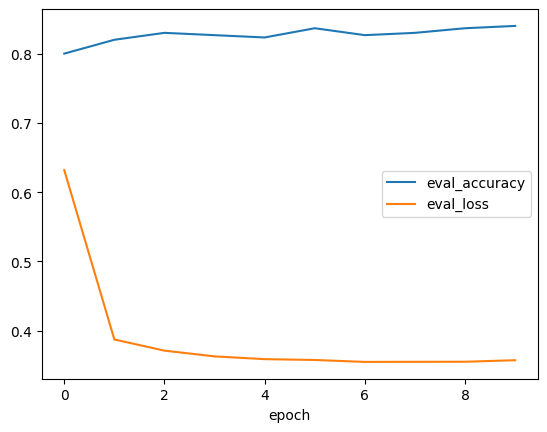

In [ ]:
trainer_qlora.save_model("./qlora_final_model")

log_history_qlora = trainer_qlora.state.log_history

get_metric_qlora = lambda metric, log_history_qlora: [log[metric] for log in log_history_qlora if metric in log]


eval_accuracy_qlora=get_metric_qlora('eval_accuracy',log_history_qlora)
eval_loss_qlora=get_metric_qlora('eval_loss',log_history_qlora)
plt.plot(eval_accuracy_qlora,label='eval_accuracy')
plt.plot(eval_loss_qlora,label='eval_loss')
plt.xlabel("epoch")
plt.legend()